In [3]:
import os
dataset_path = r"C:\Users\rathi\MWPD"  # Path to MWPD folder
data_yaml = os.path.join(dataset_path, "data.yaml")

train_images = os.path.join(dataset_path, "train/images")
val_images = os.path.join(dataset_path, "valid/images")
test_images = os.path.join(dataset_path, "test/images")

## Improved Model of YOLOv8s

In [4]:
# Load YOLOv8 pretrained model
!pip install ultralytics
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # 'n' for nano, small and fast

## Print 5 images from Train-Images Folder

In [5]:
print(os.listdir(r"C:\Users\rathi\MWPD\train\images")[:5])

['101_jpg.rf.53fab5a14aa64e331f961a80374db113.jpg', '101_jpg.rf.5fa80c95b70d3d0f580e269c7d2c3e1b.jpg', '101_jpg.rf.9f2628c6e8463a19bf5aa26b7faefbc9.jpg', '101_jpg.rf.ad3cfbf41bd4cd2d15bf683be6d9cc5b.jpg', '101_jpg.rf.db491c070dc69feaf6f364fa8a532fb1.jpg']


## Make Boundary boxes for Pothhole/Road-Damages Detection

In [6]:
import os
import cv2
import shutil

def mask_to_bboxes(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x,y,w,h = cv2.boundingRect(c)
        if w*h > 30:  # ignore tiny noise
            boxes.append((x,y,w,h))
    return boxes

def convert_split(split):
    img_dir = f"MWPD/{split}/images"
    mask_dir = f"MWPD/{split}/masks"
    out_img_dir = f"MWPD/{split}/images"
    out_lbl_dir = f"MWPD/{split}/labels"

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    for name in os.listdir(img_dir):
        if name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(img_dir, name)
            mask_path = os.path.join(mask_dir, os.path.splitext(name)[0] + ".png")  # adjust mask type if needed

            if not os.path.exists(mask_path):
                print("[WARNING] No mask for:", name)
                continue

            img = cv2.imread(img_path)
            h, w = img.shape[:2]

            mask = cv2.imread(mask_path, 0)
            _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

            boxes = mask_to_bboxes(mask)

            # copy image to YOLO dataset
            shutil.copy(img_path, os.path.join(out_img_dir, name))

            # write label file
            label_path = os.path.join(out_lbl_dir, os.path.splitext(name)[0] + ".txt")
            with open(label_path, "w") as f:
                for (x,y,bw,bh) in boxes:
                    xc = (x + bw/2) / w
                    yc = (y + bh/2) / h
                    nw = bw / w
                    nh = bh / h
                    class_id = 0  # damage class
                    f.write(f"{class_id} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}\n")

            print("Converted:", name)

for split in ["train", "valid", "test"]:
    convert_split(split)


## Configuration set-up for YOLO Packages

In [ ]:
pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.9.1Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.



Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1
Found existing installation: torchvision 0.24.1
Uninstalling torchvision-0.24.1:
  Successfully uninstalled torchvision-0.24.1


In [8]:
pip uninstall ultralytics -y


Found existing installation: ultralytics 8.3.23
Uninstalling ultralytics-8.3.23:
  Successfully uninstalled ultralytics-8.3.23
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.6.0+cpu, 2.7.0+cpu, 2.7.1+cpu, 2.8.0+cpu, 2.9.0+cpu, 2.9.1+cpu)
ERROR: No matching distribution found for torch==2.1.2


In [1]:
pip install ultralytics==8.3.23


Note: you may need to restart the kernel to use updated packages.


## Create/Initialze YOLO model (small version)

In [2]:
import torch
print(torch.__version__)

from ultralytics import YOLO
model = YOLO("yolov8s.pt")


2.9.1+cpu


## Train Yolov8s model

In [3]:
# from ultralytics import YOLO
# import os
# from ultralytics import YOLO

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# os.environ["OMP_NUM_THREADS"] = "1"


# model = YOLO("yolov8s.pt")


# Train
model.train(
    data=r"C:\Users\rathi\MWPD\data.yaml",
    imgsz=350,
    epochs=20,
    batch=4,
    workers=0,     # Important for Windows
    device="cpu",  # Use "cuda" if you have GPU
    cache=False
)



New https://pypi.org/project/ultralytics/8.3.234 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.23  Python-3.13.5 torch-2.9.1+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=C:\Users\rathi\MWPD\data.yaml, epochs=20, time=None, patience=100, batch=4, imgsz=350, save=True, save_period=-1, cache=False, device=cpu, workers=0, project=None, name=train37, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, s

train: Scanning C:\Users\rathi\MWPD\train\labels.cache... 2727 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2727/
C:\Users\rathi\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\rathi\MWPD\val\labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100%|██████████| 259/259 [0


Plotting labels to runs\detect\train37\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 352 train, 352 val
Using 0 dataloader workers
Logging results to runs\detect\train37
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/20         0G      2.016      2.152      1.762         22        352: 100%|██████████| 682/682 [19:01<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 33/33 [00:38

                   all        259        571      0.342      0.361      0.245     0.0835


...

                   all        259        571      0.775      0.664      0.749      0.369



20 epochs completed in 6.472 hours.
Optimizer stripped from runs\detect\train37\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\train37\weights\best.pt, 22.5MB

Validating runs\detect\train37\weights\best.pt...
Ultralytics 8.3.23  Python-3.13.5 torch-2.9.1+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 33/33 [00:33


                   all        259        571      0.775      0.662      0.749      0.369
Speed: 0.6ms preprocess, 112.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\train37


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F2D11FCF50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## Validate the trained model

In [4]:
from ultralytics import YOLO

model = YOLO("C:/Users/rathi/OneDrive - Umich/runs/detect/train37/weights/best.pt")

# Run full validation to generate confusion matrix, PR curves, F1 curves, labels, predictions
model.val(
    imgsz=256,
    batch=1,
    plots=False,
    save_json=False,
    save_txt=False,
    device="cpu",
    verbose=False
)

Ultralytics 8.3.23  Python-3.13.5 torch-2.9.1+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\rathi\MWPD\val\labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100%|██████████| 259/259 [0
C:\Users\rathi\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 259/259 [00:

                   all        259        571      0.796      0.654      0.741      0.361
Speed: 0.9ms preprocess, 123.2ms inference, 0.0ms loss, 1.4ms postprocess per image


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F2E4768680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## Validation done on Test Evaluation

In [7]:
# results = model.predict(
#     source=r"C:\Users\rathi\MWPD\test\images",
#     save=True,           # saves images with bounding boxes
#     conf=0.25,           # confidence threshold
#     name="pothole_test_results"
# )
from ultralytics import YOLO

# Load your trained model (best.pt)
model = YOLO("runs/detect/train37/weights/best.pt")

# Run evaluation on test set
metrics = model.val(data=r"C:\Users\rathi\MWPD\data.yaml", split="test")
print(metrics)


Ultralytics 8.3.23  Python-3.13.5 torch-2.9.1+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\rathi\MWPD\test\labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100%|██████████| 97/97 [00:
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:15<0


                   all         97        292      0.759      0.664      0.749      0.393
Speed: 0.8ms preprocess, 119.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\val29
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F2F1E11650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    

## Test Results saved in "Pothole_test_results"

In [9]:
model = YOLO("runs/detect/train37/weights/best.pt")

results = model.predict(
    source=r"C:\Users\rathi\MWPD\test\images",
    save=True,           # saves images with bounding boxes
    conf=0.25,           # confidence threshold
    name="pothole_test_results")


image 1/97 C:\Users\rathi\MWPD\test\images\12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg: 352x352 1 pothole, 204.0ms
image 2/97 C:\Users\rathi\MWPD\test\images\139_jpg.rf.f2928d6451a5fd5ef95a3051b4b2ba5a.jpg: 352x352 7 potholes, 169.3ms
image 3/97 C:\Users\rathi\MWPD\test\images\147_jpg.rf.29a0769290af2d4a69db84c5b838eae7.jpg: 352x352 13 potholes, 153.3ms
image 4/97 C:\Users\rathi\MWPD\test\images\15_jpg.rf.efee37dd5a47841089fa6fa96bcded28.jpg: 352x352 3 potholes, 158.7ms
image 5/97 C:\Users\rathi\MWPD\test\images\181_jpg.rf.f5d2a9174fcd2f2b3aa547325f9863b0.jpg: 352x352 2 potholes, 173.2ms
image 6/97 C:\Users\rathi\MWPD\test\images\19_jpg.rf.c0972876ad058389d3ec2943deae367d.jpg: 352x352 10 potholes, 153.6ms
image 7/97 C:\Users\rathi\MWPD\test\images\200_jpg.rf.93df76f6c192bf4046b2d5d2260ba518.jpg: 352x352 4 potholes, 156.2ms
image 8/97 C:\Users\rathi\MWPD\test\images\20240621_212348_jpg.rf.ae0a06a2bfa8f47d7f9a50f8c09deda8.jpg: 352x352 2 potholes, 165.1ms
image 9/97 C:\Users\rathi\MWP

## CNN Model for Classification(Optional)

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Custom Dataset for YOLO-style directory with labels/

class YOLOClassificationDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        # Open image
        image = Image.open(img_path).convert("RGB")

        # YOLO label file:
        label_file = os.path.join(self.labels_dir, img_name.replace(".jpg", ".txt"))

        # if label file exists and is non-empty → pothole present
        if os.path.exists(label_file) and os.path.getsize(label_file) > 0:
            label = 1     # pothole present
        else:
            label = 0     # no pothole

        if self.transform:
            image = transform(image)

        return image, label


# 2. Directories

train_img = r"C:\Users\rathi\MWPD\train\images"
train_lbl = r"C:\Users\rathi\MWPD\train\labels"

val_img   = r"C:\Users\rathi\MWPD\val\images"
val_lbl   = r"C:\Users\rathi\MWPD\val\labels"

test_img  = r"C:\Users\rathi\MWPD\test\images"
test_lbl  = r"C:\Users\rathi\MWPD\test\labels"


# 3. Transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


# 4. Load datasets

train_dataset = YOLOClassificationDataset(train_img, train_lbl, transform)
val_dataset   = YOLOClassificationDataset(val_img, val_lbl, transform)
test_dataset  = YOLOClassificationDataset(test_img, test_lbl, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


# 5. CNN Model (ResNet18)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # binary classification
device = "cpu"
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 6. Training Loop

EPOCHS = 10
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")


# 7. Evaluate on Test Set

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\nTEST RESULTS")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("Confusion Matrix:")
print(cm)


Epoch 1/10 | Train Loss: 0.0460 | Val Loss: 0.0016
Epoch 2/10 | Train Loss: 0.0011 | Val Loss: 0.0006
Epoch 3/10 | Train Loss: 0.0006 | Val Loss: 0.0005
Epoch 4/10 | Train Loss: 0.0003 | Val Loss: 0.0003
Epoch 5/10 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch 6/10 | Train Loss: 0.0002 | Val Loss: 0.0001
Epoch 7/10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 8/10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 9/10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 10/10 | Train Loss: 0.0001 | Val Loss: 0.0000

TEST RESULTS
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Confusion Matrix:
[[97]]


C:\Users\rathi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


<Figure size 640x480 with 1 Axes>

In [18]:
%matplotlib inline


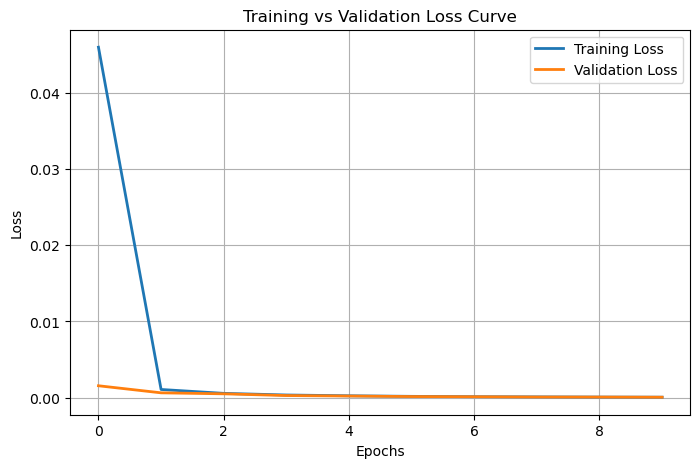

In [19]:
from IPython.display import display

# 8. Plot Loss Graph
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.grid(True)
plt.legend()

display(plt.gcf())  # <<< forces Jupyter to display the figure
